# RQ1 and RQ2 Topic Post-processing
# RQ1与RQ2主题后处理

This notebook uses the completed baseline and advanced clustering outputs. It does not rerun Sentence Transformer, UMAP, or HDBSCAN, and it does not use stance data.

本notebook使用已经完成的基线与高级聚类结果，不重新运行Sentence Transformer、UMAP或HDBSCAN，也不使用stance数据。

It corrects topic terms, adds reviewed micro-topic and macro-topic names, separates noise and excluded false-positive topics, and compares communities at comment and post levels.

它会修正主题关键词、添加人工审核后的微观和宏观主题名称、区分噪声与误匹配主题，并从评论级和帖子级比较社区。

## 1. Setup and input checks / 1. 设置与输入检查

Load the completed clustered Parquet and the representative-comment table. Output paths remain inside D:\DM1_project.

读取已经完成的聚类Parquet和代表性评论表。输出路径仍位于D:\DM1_project。

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import seaborn as sns
from IPython.display import display
from scipy.sparse import diags
from scipy.stats import chi2_contingency
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer
from sklearn.preprocessing import normalize

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titleweight"] = "bold"

BASE_DIR = Path(r"D:\DM1_project")
INPUT_PATH = BASE_DIR / "reddit_climate_baseline_advanced_clusters.parquet"
CLUSTER_OUTPUT_DIR = BASE_DIR / "baseline_vs_advanced_outputs"
REPRESENTATIVES_PATH = CLUSTER_OUTPUT_DIR / "advanced_representative_comments.csv"
OUTPUT_DIR = BASE_DIR / "topic_postprocessing_outputs"
FINAL_PATH = BASE_DIR / "reddit_climate_final_topics.parquet"

# Codex uses this only to validate the notebook without writing to D:.
# Normal local execution leaves this False and saves all outputs.
VALIDATION_ONLY = os.environ.get("DM1_VALIDATION_ONLY", "0") == "1"

SELECTED_SUBREDDITS = [
    "climatechange", "climate", "energy",
    "Futurology", "conspiracy", "changemyview",
]
RANDOM_STATE = 42
MAX_TERM_SAMPLE_PER_TOPIC = 4_000

assert INPUT_PATH.exists(), f"Missing clustered data: {INPUT_PATH}"
assert REPRESENTATIVES_PATH.exists(), f"Missing representatives: {REPRESENTATIVES_PATH}"
print("Input:", INPUT_PATH)
print("Output directory:", OUTPUT_DIR)
print("Validation-only mode:", VALIDATION_ONLY)

Input: D:\DM1_project\reddit_climate_baseline_advanced_clusters.parquet
Output directory: D:\DM1_project\topic_postprocessing_outputs
Validation-only mode: True


Result: Both required inputs were found and the complete post-processing workflow was validated without modifying the source files.

结果：两个必需输入均已找到，完整后处理流程已通过验证，且未修改源文件。

## 2. Load the completed clustering data / 2. 读取已完成的聚类数据

Read the full assigned corpus and verify row identity, dates, labels, and missing values before post-processing.

读取全部已分配语料，并在后处理前验证行标识、日期、标签和缺失值。

In [2]:
dataset = ds.dataset(INPUT_PATH, format="parquet")
topic_df = dataset.to_table().to_pandas()

integrity_summary = pd.DataFrame({
    "metric": [
        "rows", "unique_comment_ids", "duplicate_comment_ids",
        "unique_posts", "baseline_clusters", "advanced_labels_including_noise",
        "baseline_label_missing", "advanced_label_missing",
    ],
    "value": [
        len(topic_df), topic_df["comment_id"].nunique(), topic_df["comment_id"].duplicated().sum(),
        topic_df["post_id"].nunique(), topic_df["baseline_cluster"].nunique(),
        topic_df["advanced_cluster"].nunique(), topic_df["baseline_cluster"].isna().sum(),
        topic_df["advanced_cluster"].isna().sum(),
    ],
})
display(integrity_summary)
print("Date range:", topic_df["created_time"].min(), "to", topic_df["created_time"].max())
display(
    topic_df.groupby("subreddit").agg(
        comments=("comment_id", "size"),
        posts=("post_id", "nunique"),
        authors=("author_name", "nunique"),
    ).reindex(SELECTED_SUBREDDITS)
)

,metric,value
0,rows,330273
1,unique_comment_ids,330273
2,duplicate_comment_ids,0
3,unique_posts,17772
4,baseline_clusters,10
5,advanced_labels_including_noise,31
6,baseline_label_missing,0
7,advanced_label_missing,0


Date range: 2023-11-19 00:00:25 to 2026-08-31 23:51:27


,comments,posts,authors
subreddit,,,
climatechange,123143,4982,26005
climate,88133,8842,20701
energy,64487,2653,18430
Futurology,32522,551,14264
conspiracy,10621,605,4587
changemyview,11367,139,4376


Result: The corpus contains 330,273 unique comments from 17,772 posts. There are no duplicate comment IDs or missing cluster labels; the advanced labels cover -1 through 29.

结果：语料包含来自17,772个帖子的330,273条唯一评论。comment_id没有重复，聚类标签没有缺失，高级标签覆盖-1至29。

## 3. Apply reviewed topic names and analysis status / 3. 应用人工审核后的主题名称与分析状态

Map each advanced cluster to a bilingual micro-topic, a broader macro-topic, and one of three statuses: core, excluded, or noise.

把每个高级聚类映射到双语微观主题、宏观主题和三种状态之一：核心、排除或噪声。

In [3]:
TOPIC_MAP = {
    -1: ("Noise / unassigned", "噪声／未分配", "Noise / unassigned", "噪声／未分配", "noise"),
    0: ("Political climate false positive", "政治环境误匹配", "Excluded false positives", "排除的误匹配", "excluded"),
    1: ("Indirect demography and feminism comparison", "人口与女权的间接比较", "Excluded false positives", "排除的误匹配", "excluded"),
    2: ("Climate misinformation and platform moderation", "气候错误信息与平台管理", "Denial, skepticism and misinformation", "否认、怀疑与错误信息", "core"),
    3: ("Population, parenthood and climate", "人口、生育与气候", "Responsibility, justice and collective action", "责任、公正与集体行动", "core"),
    4: ("Climate activism and protest tactics", "气候行动主义与抗议策略", "Politics and activism", "政治与行动主义", "core"),
    5: ("Electric vehicles and transport transition", "电动车与交通转型", "Transport electrification", "交通电气化", "core"),
    6: ("Food security and climate-related malnutrition", "粮食安全与气候相关营养不良", "Climate impacts and adaptation", "气候影响与适应", "core"),
    7: ("Meat, vegan diets and livestock emissions", "肉类、纯素饮食与畜牧排放", "Food systems and consumption", "食物系统与消费", "core"),
    8: ("Green hydrogen", "绿色氢能", "Energy technologies", "能源技术", "core"),
    9: ("Carbon inequality and wealthy emitters", "碳不平等与高排放富裕群体", "Responsibility, justice and collective action", "责任、公正与集体行动", "core"),
    10: ("Carbon capture and removal", "碳捕集与清除", "Carbon management and emerging technology", "碳管理与新兴技术", "core"),
    11: ("Fossil-fuel phase-out", "化石燃料淘汰", "Energy transition and fossil fuels", "能源转型与化石燃料", "core"),
    12: ("AI data centres and climate", "AI数据中心与气候", "Carbon management and emerging technology", "碳管理与新兴技术", "core"),
    13: ("Nuclear-power debate", "核电争论", "Energy technologies", "能源技术", "core"),
    14: ("US clean-energy politics", "美国清洁能源政治", "Energy transition and fossil fuels", "能源转型与化石燃料", "core"),
    15: ("China's clean-energy transition", "中国清洁能源转型", "Energy transition and fossil fuels", "能源转型与化石燃料", "core"),
    16: ("Renewable-power economics and grids", "可再生能源经济与电网", "Energy transition and fossil fuels", "能源转型与化石燃料", "core"),
    17: ("US climate politics and elections", "美国气候政治与选举", "Politics and activism", "政治与行动主义", "core"),
    18: ("Sea-level rise and ice melt", "海平面上升与冰层融化", "Climate impacts and adaptation", "气候影响与适应", "core"),
    19: ("Wildfire attribution and conspiracy", "野火归因与阴谋论", "Denial, skepticism and misinformation", "否认、怀疑与错误信息", "core"),
    20: ("Heatwaves and heat risk", "热浪与高温风险", "Climate impacts and adaptation", "气候影响与适应", "core"),
    21: ("Winter, snow and local climate experience", "冬季、降雪与本地气候体验", "Climate impacts and adaptation", "气候影响与适应", "core"),
    22: ("Insurance, flooding and climate migration", "保险、洪水与气候迁移", "Climate impacts and adaptation", "气候影响与适应", "core"),
    23: ("Drought, hurricanes and the water cycle", "干旱、飓风与水循环", "Climate impacts and adaptation", "气候影响与适应", "core"),
    24: ("Collective-action dilemma and mitigation pessimism", "集体行动困境与减缓悲观主义", "Responsibility, justice and collective action", "责任、公正与集体行动", "core"),
    25: ("Individual versus corporate responsibility", "个人责任与企业责任", "Responsibility, justice and collective action", "责任、公正与集体行动", "core"),
    26: ("Personal action and systemic solutions", "个人行动与系统性解决方案", "Responsibility, justice and collective action", "责任、公正与集体行动", "core"),
    27: ("Climate-scam and failed-prediction narratives", "气候骗局与预测失败叙事", "Denial, skepticism and misinformation", "否认、怀疑与错误信息", "core"),
    28: ("CO2 attribution skepticism", "CO2归因怀疑", "Denial, skepticism and misinformation", "否认、怀疑与错误信息", "core"),
    29: ("1.5C threshold and warming targets", "1.5°C阈值与升温目标", "Climate science and warming targets", "气候科学与升温目标", "core"),
}

MACRO_ORDER = [
    "Climate science and warming targets",
    "Denial, skepticism and misinformation",
    "Climate impacts and adaptation",
    "Energy transition and fossil fuels",
    "Energy technologies",
    "Transport electrification",
    "Carbon management and emerging technology",
    "Food systems and consumption",
    "Politics and activism",
    "Responsibility, justice and collective action",
]

topic_dictionary = pd.DataFrame.from_dict(
    TOPIC_MAP, orient="index",
    columns=["micro_topic", "micro_topic_zh", "macro_topic", "macro_topic_zh", "analysis_status"],
).rename_axis("advanced_cluster").reset_index()

topic_df = topic_df.merge(topic_dictionary, on="advanced_cluster", how="left", validate="many_to_one")
assert topic_df["analysis_status"].notna().all(), "Unmapped advanced cluster found"
display(topic_dictionary)
display(
    topic_df.groupby("analysis_status").size().rename("comments").to_frame()
    .assign(percent=lambda x: x["comments"] / len(topic_df) * 100)
)

,advanced_cluster,micro_topic,micro_topic_zh,macro_topic,macro_topic_zh,analysis_status
0,-1,Noise / unassigned,噪声／未分配,Noise / unassigned,噪声／未分配,noise
1,0,Political climate false positive,政治环境误匹配,Excluded false positives,排除的误匹配,excluded
2,1,Indirect demography and feminism comparison,人口与女权的间接比较,Excluded false positives,排除的误匹配,excluded
3,2,Climate misinformation and platform moderation,气候错误信息与平台管理,"Denial, skepticism and misinformation",否认、怀疑与错误信息,core
4,3,"Population, parenthood and climate",人口、生育与气候,"Responsibility, justice and collective action",责任、公正与集体行动,core
5,4,Climate activism and protest tactics,气候行动主义与抗议策略,Politics and activism,政治与行动主义,core
6,5,Electric vehicles and transport transition,电动车与交通转型,Transport electrification,交通电气化,core
7,6,Food security and climate-related malnutrition,粮食安全与气候相关营养不良,Climate impacts and adaptation,气候影响与适应,core
8,7,"Meat, vegan diets and livestock emissions",肉类、纯素饮食与畜牧排放,Food systems and consumption,食物系统与消费,core
9,8,Green hydrogen,绿色氢能,Energy technologies,能源技术,core


,comments,percent
analysis_status,,
core,164939,49.940201
excluded,1795,0.543490
noise,163539,49.516309


Result: The reviewed mapping retains 164,939 core comments (49.94%), keeps 163,539 comments as noise (49.52%), and excludes 1,795 false-positive comments (0.54%). Clusters 2-29 form ten macro-topics.

结果：人工审核映射保留164,939条核心评论（49.94%），保留163,539条噪声评论（49.52%），排除1,795条误匹配评论（0.54%）。聚类2至29组成10个宏观主题。

## 4. Recalculate clean c-TF-IDF terms / 4. 重新计算干净的c-TF-IDF关键词

Remove the literal SEP token from topic descriptions and recalculate terms on a controlled sample of the full assigned corpus. Cluster assignments do not change.

从主题描述中移除SEP字面标记，并在完整已分配语料的受控样本上重新计算关键词。聚类标签不会改变。

In [4]:
core_df = topic_df.loc[topic_df["analysis_status"].eq("core")].copy()
term_sample_parts = []
for cluster_id, group in core_df.groupby("advanced_cluster"):
    term_sample_parts.append(group.sample(
        n=min(MAX_TERM_SAMPLE_PER_TOPIC, len(group)),
        random_state=RANDOM_STATE,
    ))
term_sample = pd.concat(term_sample_parts, ignore_index=True)
term_sample["term_text"] = (
    term_sample["post_title"].fillna("").astype(str)
    + " "
    + term_sample["clean_text"].fillna("").astype(str)
).str.replace(r"\[?SEP\]?", " ", regex=True, case=False)

grouped_text = term_sample.groupby("advanced_cluster")["term_text"].agg(" ".join).sort_index()
stop_words = sorted(set(ENGLISH_STOP_WORDS) | {"sep"})
term_vectorizer = CountVectorizer(
    stop_words=stop_words,
    ngram_range=(1, 2),
    min_df=1,
    max_features=50_000,
)
counts = term_vectorizer.fit_transform(grouped_text)
class_tf = normalize(counts, norm="l1", axis=1)
document_frequency = np.asarray((counts > 0).sum(axis=0)).ravel()
average_words = float(np.asarray(counts.sum(axis=1)).mean())
ctfidf = class_tf @ diags(np.log1p(average_words / np.maximum(document_frequency, 1)))
vocabulary = term_vectorizer.get_feature_names_out()

term_rows = []
for row_position, cluster_id in enumerate(grouped_text.index):
    weights = ctfidf.getrow(row_position).toarray().ravel()
    for rank, term_index in enumerate(weights.argsort()[::-1][:20], start=1):
        term_rows.append({
            "advanced_cluster": int(cluster_id),
            "rank": rank,
            "term": vocabulary[term_index],
            "weight": weights[term_index],
        })
corrected_terms = pd.DataFrame(term_rows).merge(
    topic_dictionary[["advanced_cluster", "micro_topic", "micro_topic_zh", "macro_topic"]],
    on="advanced_cluster", how="left",
)
assert not corrected_terms["term"].str.contains(r"\bsep\b", case=False, regex=True).any()

term_overview = corrected_terms.loc[corrected_terms["rank"].le(10)].groupby(
    ["advanced_cluster", "micro_topic"], sort=True
)["term"].agg(lambda values: ", ".join(values)).reset_index(name="top_terms")
display(term_overview)

,advanced_cluster,micro_topic,top_terms
0,2,Climate misinformation and platform moderation,"climate, change, climate change, people, like,..."
1,3,"Population, parenthood and climate","climate, change, climate change, people, kids,..."
2,4,Climate activism and protest tactics,"climate, people, just, oil, stop, change, prot..."
3,5,Electric vehicles and transport transition,"ev, electric, vehicles, evs, trump, electric v..."
4,6,Food security and climate-related malnutrition,"climate, food, change, climate change, crops, ..."
5,7,"Meat, vegan diets and livestock emissions","climate, meat, emissions, people, change, beef..."
6,8,Green hydrogen,"hydrogen, energy, green, fuel, gas, clean, jus..."
7,9,Carbon inequality and wealthy emitters,"emissions, climate, people, carbon, flying, wo..."
8,10,Carbon capture and removal,"carbon, co2, capture, climate, trees, carbon c..."
9,11,Fossil-fuel phase-out,"fossil, oil, fuels, fossil fuels, fuel, fossil..."


Result: The recalculated terms contain no SEP token. All 28 retained micro-topics have clean top-term lists, while their original cluster assignments remain unchanged.

结果：重新计算后的关键词不再包含SEP。28个保留微观主题都有干净的关键词列表，原始聚类标签保持不变。

## 5. RQ1 macro-topic summaries / 5. RQ1宏观主题汇总

Summarize the ten core macro-topics and retain the micro-topic dictionary as the detailed RQ1 result.

汇总10个核心宏观主题，同时保留微观主题字典作为RQ1的详细结果。

,macro_topic,macro_topic_zh,comments,posts,authors,median_words,median_score,controversial_rate,micro_topics,share_of_core_comments
0,Climate science and warming targets,气候科学与升温目标,6989,1181,3276,40.0,2.0,0.028044,1,0.042373
1,"Denial, skepticism and misinformation",否认、怀疑与错误信息,13214,2164,6058,48.0,2.0,0.040714,4,0.080114
2,Climate impacts and adaptation,气候影响与适应,23182,3305,10537,41.0,2.0,0.019886,6,0.140549
3,Energy transition and fossil fuels,能源转型与化石燃料,44685,4019,16596,42.0,2.0,0.026855,4,0.270918
4,Energy technologies,能源技术,10476,1049,4463,52.0,2.0,0.057083,2,0.063514
5,Transport electrification,交通电气化,16961,1300,8238,45.0,2.0,0.028831,1,0.102832
6,Carbon management and emerging technology,碳管理与新兴技术,11114,1736,5394,46.0,2.0,0.024474,2,0.067382
7,Food systems and consumption,食物系统与消费,6654,808,2854,49.0,2.0,0.074992,1,0.040342
8,Politics and activism,政治与行动主义,16000,2285,7445,40.0,2.0,0.043437,2,0.097006
9,"Responsibility, justice and collective action",责任、公正与集体行动,15664,2053,8796,48.0,2.0,0.036070,5,0.094968


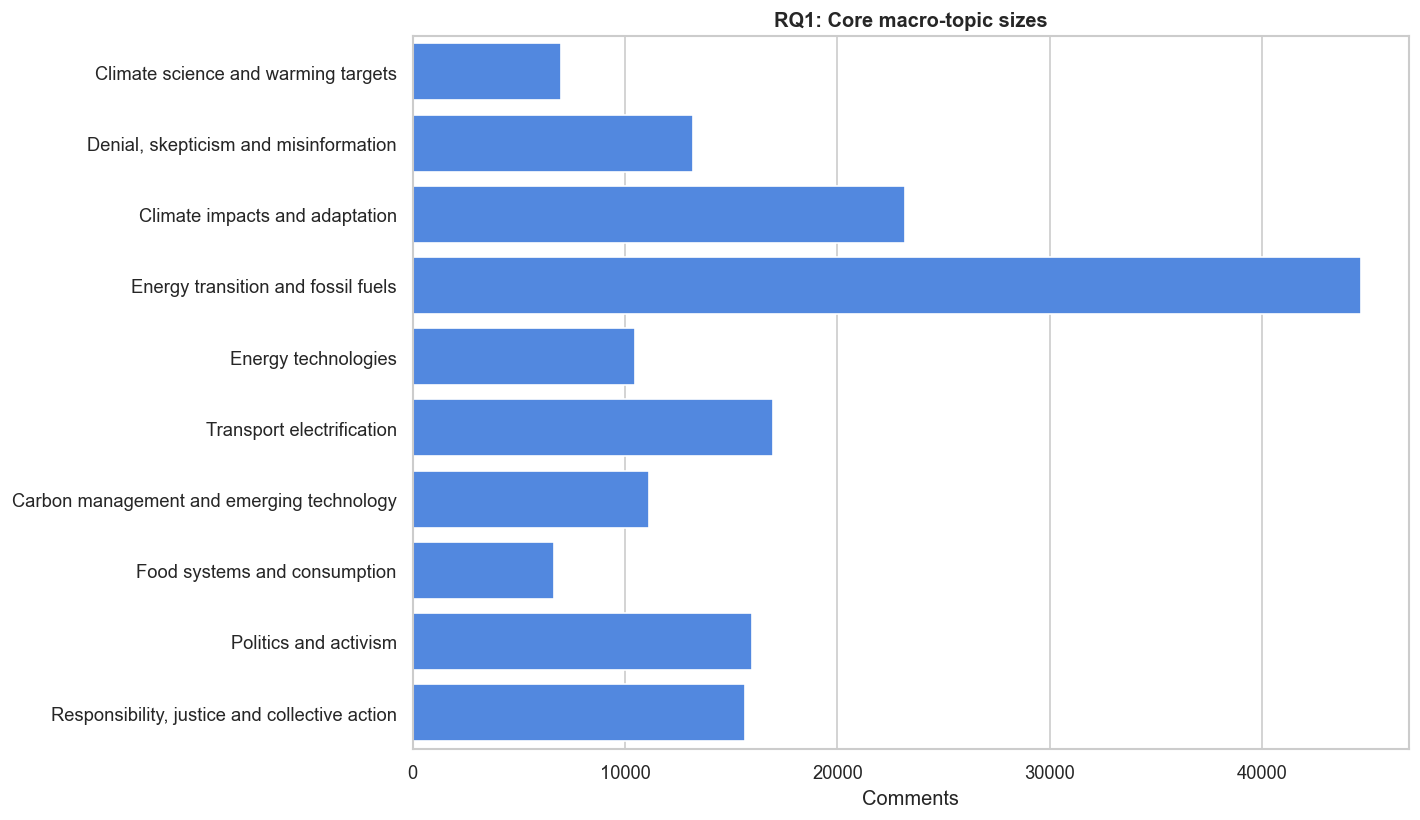

In [5]:
core_df["macro_topic"] = pd.Categorical(core_df["macro_topic"], categories=MACRO_ORDER, ordered=True)
macro_summary = (
    core_df.groupby(["macro_topic", "macro_topic_zh"], observed=True)
    .agg(
        comments=("comment_id", "size"),
        posts=("post_id", "nunique"),
        authors=("author_name", "nunique"),
        median_words=("comment_word_count", "median"),
        median_score=("score", "median"),
        controversial_rate=("controversiality", "mean"),
        micro_topics=("advanced_cluster", "nunique"),
    )
    .reset_index()
)
macro_summary["share_of_core_comments"] = macro_summary["comments"] / len(core_df)
display(macro_summary)

fig, ax = plt.subplots(figsize=(12, 7))
plot_summary = macro_summary.sort_values("comments", ascending=True)
sns.barplot(data=plot_summary, y="macro_topic", x="comments", color="#3B82F6", ax=ax)
ax.set_title("RQ1: Core macro-topic sizes")
ax.set_xlabel("Comments")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Result: Energy transition and fossil fuels is the largest macro-topic with 44,685 comments (27.09% of the core corpus), followed by climate impacts and adaptation with 23,182 (14.05%) and transport electrification with 16,961 (10.28%).

结果：能源转型与化石燃料是最大的宏观主题，共44,685条评论，占核心语料27.09%；其后是气候影响与适应23,182条（14.05%）和交通电气化16,961条（10.28%）。

## 6. Coverage, noise, and excluded-topic audit / 6. 覆盖率、噪声与排除主题审计

Report how much of each community is core, noise, or excluded before comparing topic percentages.

在比较主题百分比前，报告每个社区中核心、噪声和排除内容的比例。

analysis_status,core,excluded,noise
subreddit,,,
climatechange,51509,137,71497
climate,43645,102,44386
energy,44024,19,20444
Futurology,16687,187,15648
conspiracy,3465,297,6859
changemyview,5609,1053,4705


analysis_status,core,excluded,noise
subreddit,,,
climatechange,41.83,0.11,58.06
climate,49.52,0.12,50.36
energy,68.27,0.03,31.70
Futurology,51.31,0.57,48.12
conspiracy,32.62,2.80,64.58
changemyview,49.34,9.26,41.39


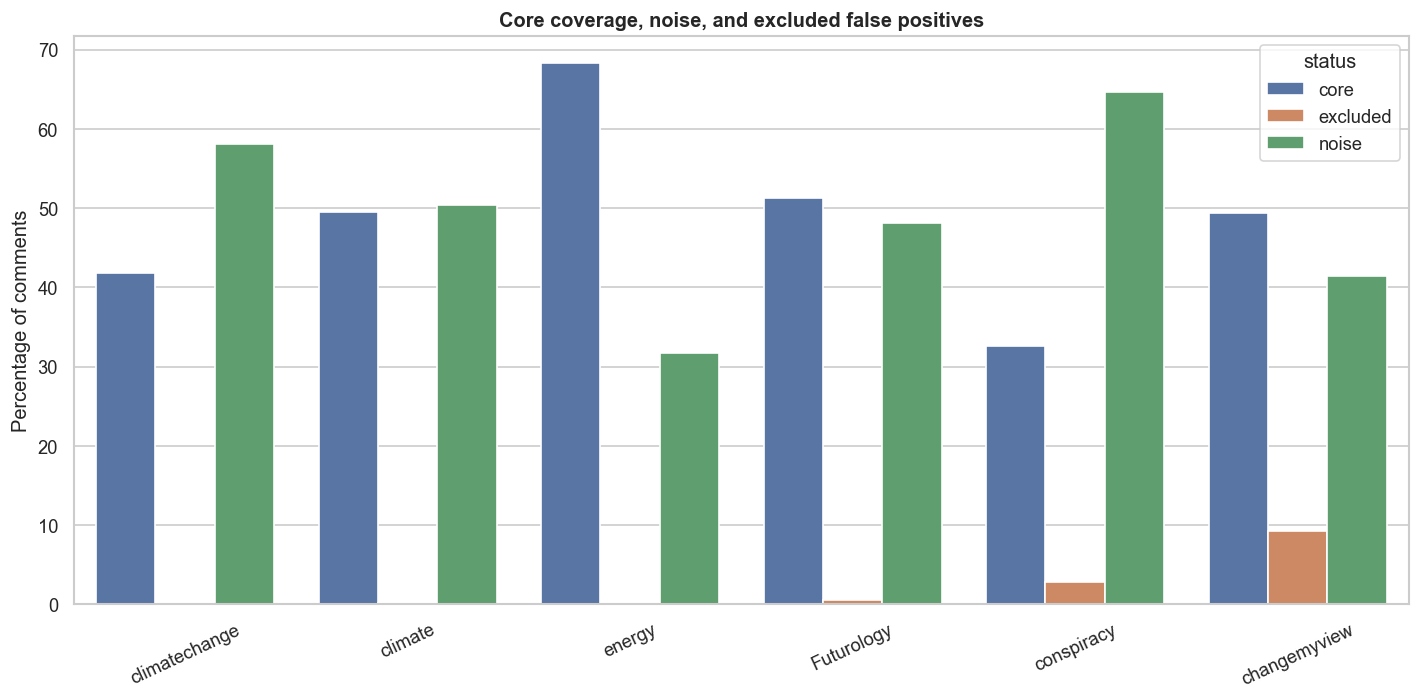

In [6]:
status_counts = pd.crosstab(topic_df["subreddit"], topic_df["analysis_status"]).reindex(SELECTED_SUBREDDITS, fill_value=0)
status_percentages = status_counts.div(status_counts.sum(axis=1), axis=0) * 100
display(status_counts)
display(status_percentages.round(2))

status_long = status_percentages.reset_index().melt(
    id_vars="subreddit", var_name="status", value_name="percent"
)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=status_long, x="subreddit", y="percent", hue="status", ax=ax)
ax.set_title("Core coverage, noise, and excluded false positives")
ax.set_ylabel("Percentage of comments")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

Result: Core coverage is highest in energy (68.27%) and lowest in conspiracy (32.62%). Changemyview has the largest excluded false-positive share (9.26%), so topic percentages must be interpreted with the coverage audit.

结果：energy的核心覆盖率最高（68.27%），conspiracy最低（32.62%）。changemyview的误匹配排除比例最高（9.26%），因此主题百分比必须结合覆盖率审计解读。

## 7. RQ2 at comment and post levels / 7. 评论级与帖子级RQ2

Calculate comment-level percentages, equal-post-weighted percentages, and one dominant macro-topic per post. This tests whether large discussions drive the findings.

计算评论级百分比、帖子等权百分比和每帖一个主导宏观主题，用于检验大型讨论是否主导结果。

In [7]:
def cramers_v_from_table(table):
    chi2, p_value, dof, expected = chi2_contingency(table)
    n = table.to_numpy().sum()
    denominator = max(1, min(table.shape[0] - 1, table.shape[1] - 1))
    return chi2, p_value, dof, np.sqrt((chi2 / n) / denominator), expected


comment_counts = pd.crosstab(core_df["subreddit"], core_df["macro_topic"]).reindex(
    index=SELECTED_SUBREDDITS, columns=MACRO_ORDER, fill_value=0
)
comment_percentages = comment_counts.div(comment_counts.sum(axis=1), axis=0) * 100

core_df["core_comments_in_post"] = core_df.groupby(["subreddit", "post_id"])["comment_id"].transform("size")
core_df["equal_post_weight"] = 1 / core_df["core_comments_in_post"]
post_weighted_counts = core_df.groupby(["subreddit", "macro_topic"], observed=True)["equal_post_weight"].sum().unstack(fill_value=0)
post_weighted_counts = post_weighted_counts.reindex(index=SELECTED_SUBREDDITS, columns=MACRO_ORDER, fill_value=0)
post_weighted_percentages = post_weighted_counts.div(post_weighted_counts.sum(axis=1), axis=0) * 100

post_topic_counts = (
    core_df.groupby(["subreddit", "post_id", "macro_topic"], observed=True)
    .size().rename("comments").reset_index()
)
dominant_post_topics = (
    post_topic_counts.sort_values(
        ["subreddit", "post_id", "comments", "macro_topic"],
        ascending=[True, True, False, True],
    )
    .drop_duplicates(["subreddit", "post_id"])
)
dominant_post_counts = pd.crosstab(
    dominant_post_topics["subreddit"], dominant_post_topics["macro_topic"]
).reindex(index=SELECTED_SUBREDDITS, columns=MACRO_ORDER, fill_value=0)
dominant_post_percentages = dominant_post_counts.div(dominant_post_counts.sum(axis=1), axis=0) * 100

comment_minus_post_weighted = comment_percentages - post_weighted_percentages
comment_stats = cramers_v_from_table(comment_counts)
post_stats = cramers_v_from_table(dominant_post_counts)
association_summary = pd.DataFrame([
    {"unit": "comments", "chi_square": comment_stats[0], "p_value": comment_stats[1], "degrees_of_freedom": comment_stats[2], "cramers_v": comment_stats[3]},
    {"unit": "dominant topic per post", "chi_square": post_stats[0], "p_value": post_stats[1], "degrees_of_freedom": post_stats[2], "cramers_v": post_stats[3]},
])

display(comment_percentages.round(2))
display(post_weighted_percentages.round(2))
display(dominant_post_percentages.round(2))
display(association_summary)

largest_sensitivity_differences = (
    comment_minus_post_weighted.abs().stack().sort_values(ascending=False)
    .head(20).rename("absolute_percentage_point_difference").reset_index()
)
display(largest_sensitivity_differences)

macro_topic,Climate science and warming targets,"Denial, skepticism and misinformation",Climate impacts and adaptation,Energy transition and fossil fuels,Energy technologies,Transport electrification,Carbon management and emerging technology,Food systems and consumption,Politics and activism,"Responsibility, justice and collective action"
subreddit,,,,,,,,,,
climatechange,7.45,16.47,23.98,10.70,6.04,4.47,9.79,3.41,4.35,13.31
climate,5.94,4.56,19.39,11.69,3.39,4.34,6.65,9.44,23.68,10.93
energy,0.02,0.35,0.36,64.24,6.12,20.25,2.31,0.12,5.86,0.36
Futurology,3.16,2.21,9.63,33.42,9.98,16.07,10.57,2.01,2.18,10.77
conspiracy,0.58,56.39,12.87,5.51,3.52,5.71,5.02,4.36,2.14,3.90
changemyview,0.02,4.72,2.76,0.45,24.96,17.24,3.80,4.12,7.29,34.64


macro_topic,Climate science and warming targets,"Denial, skepticism and misinformation",Climate impacts and adaptation,Energy transition and fossil fuels,Energy technologies,Transport electrification,Carbon management and emerging technology,Food systems and consumption,Politics and activism,"Responsibility, justice and collective action"
subreddit,,,,,,,,,,
climatechange,8.93,16.77,26.65,11.28,3.30,3.43,10.67,2.65,4.37,11.95
climate,5.77,7.48,22.51,14.61,2.46,2.92,7.56,4.83,21.92,9.95
energy,0.13,1.01,1.10,66.16,10.29,9.27,5.13,0.52,5.59,0.80
Futurology,2.35,2.64,9.41,35.88,11.90,10.00,13.69,3.31,3.08,7.74
conspiracy,1.96,43.45,17.72,5.76,3.78,6.21,4.68,4.68,5.50,6.26
changemyview,0.02,3.67,6.75,3.57,16.48,11.45,6.35,1.57,4.07,46.08


macro_topic,Climate science and warming targets,"Denial, skepticism and misinformation",Climate impacts and adaptation,Energy transition and fossil fuels,Energy technologies,Transport electrification,Carbon management and emerging technology,Food systems and consumption,Politics and activism,"Responsibility, justice and collective action"
subreddit,,,,,,,,,,
climatechange,9.49,18.13,27.39,11.33,3.00,2.97,9.96,2.22,3.75,11.77
climate,6.41,7.77,22.98,14.63,2.35,2.78,7.37,4.56,21.82,9.34
energy,0.14,1.16,1.06,68.52,9.71,7.95,4.90,0.46,5.36,0.74
Futurology,2.67,2.90,9.58,37.64,11.14,8.91,13.81,2.90,2.90,7.57
conspiracy,2.12,45.76,17.88,6.06,3.64,6.06,4.24,4.55,4.55,5.15
changemyview,0.00,4.00,7.00,4.00,16.00,11.00,5.00,1.00,4.00,48.00


,unit,chi_square,p_value,degrees_of_freedom,cramers_v
0,comments,108664.438257,0.0,45,0.362992
1,dominant topic per post,5888.713439,0.0,45,0.302696


,subreddit,macro_topic,absolute_percentage_point_difference
0,conspiracy,"Denial, skepticism and misinformation",12.945631
1,changemyview,"Responsibility, justice and collective action",11.443261
2,energy,Transport electrification,10.984413
3,changemyview,Energy technologies,8.477631
4,Futurology,Transport electrification,6.076929
5,changemyview,Transport electrification,5.789010
6,conspiracy,Climate impacts and adaptation,4.847642
7,climate,Food systems and consumption,4.614825
8,energy,Energy technologies,4.165565
9,changemyview,Climate impacts and adaptation,3.988183


Result: Community-topic association remains substantial after changing the unit from comments (Cramer's V = 0.363) to one dominant topic per post (Cramer's V = 0.303). The largest sensitivity changes are conspiracy denial topics (12.95 percentage points) and changemyview responsibility topics (11.44 points).

结果：把分析单位从评论改为每帖一个主导主题后，社区—主题关联仍然存在：评论级Cramer's V为0.363，帖子级为0.303。最大敏感性变化来自conspiracy的否认主题（12.95个百分点）和changemyview的责任主题（11.44个百分点）。

## 8. Final RQ2 visual comparison / 8. 最终RQ2可视化比较

Plot comment-level and post-weighted topic distributions side by side, plus their percentage-point difference.

并列绘制评论级和帖子加权主题分布，并展示两者的百分点差异。

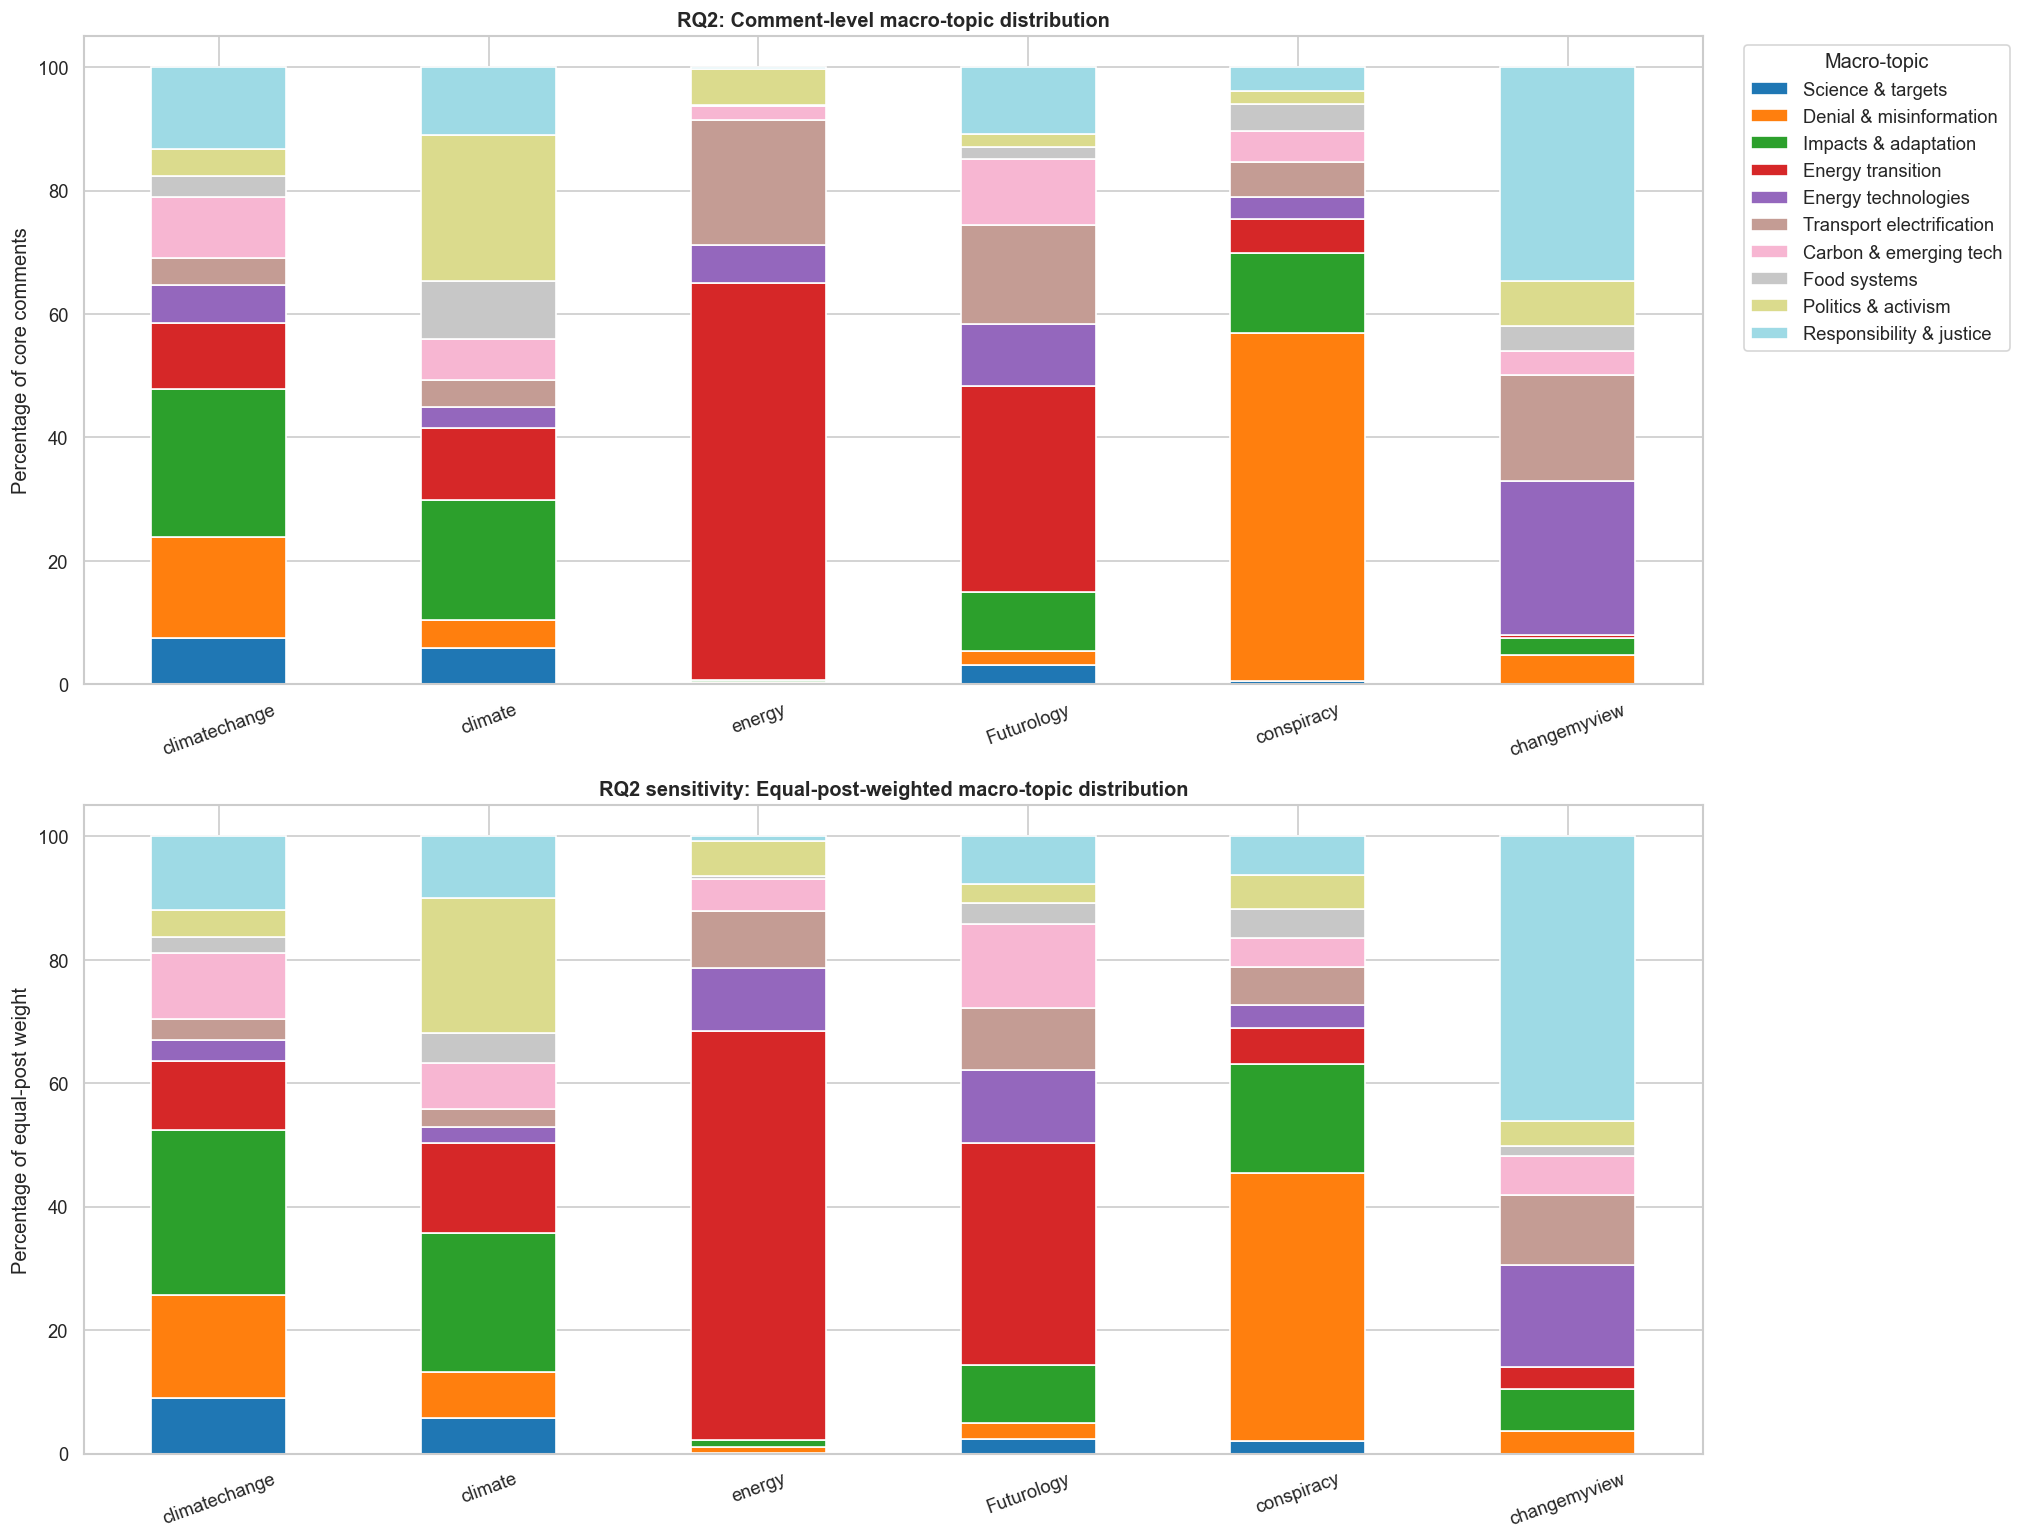

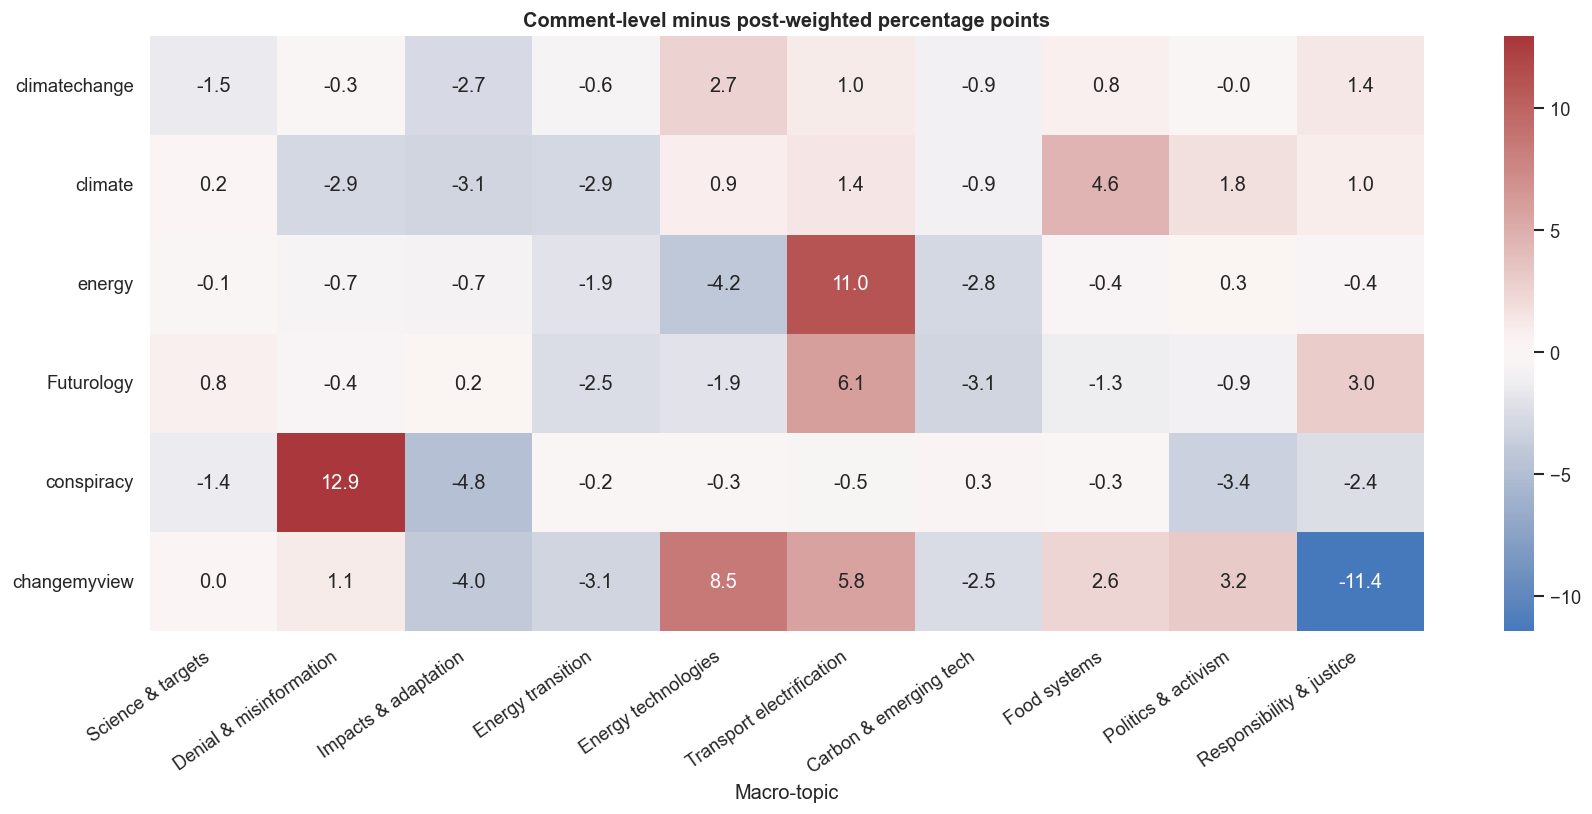

In [8]:
PLOT_TOPIC_LABELS = {
    "Climate science and warming targets": "Science & targets",
    "Denial, skepticism and misinformation": "Denial & misinformation",
    "Climate impacts and adaptation": "Impacts & adaptation",
    "Energy transition and fossil fuels": "Energy transition",
    "Energy technologies": "Energy technologies",
    "Transport electrification": "Transport electrification",
    "Carbon management and emerging technology": "Carbon & emerging tech",
    "Food systems and consumption": "Food systems",
    "Politics and activism": "Politics & activism",
    "Responsibility, justice and collective action": "Responsibility & justice",
}
comment_plot = comment_percentages.rename(columns=PLOT_TOPIC_LABELS)
post_weighted_plot = post_weighted_percentages.rename(columns=PLOT_TOPIC_LABELS)
difference_plot = comment_minus_post_weighted.rename(columns=PLOT_TOPIC_LABELS)

fig, axes = plt.subplots(2, 1, figsize=(17, 13))
comment_plot.plot(kind="bar", stacked=True, colormap="tab20", ax=axes[0])
axes[0].set_title("RQ2: Comment-level macro-topic distribution")
axes[0].set_ylabel("Percentage of core comments")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="Macro-topic", bbox_to_anchor=(1.02, 1), loc="upper left")

post_weighted_plot.plot(kind="bar", stacked=True, colormap="tab20", ax=axes[1], legend=False)
axes[1].set_title("RQ2 sensitivity: Equal-post-weighted macro-topic distribution")
axes[1].set_ylabel("Percentage of equal-post weight")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(difference_plot, center=0, cmap="vlag", annot=True, fmt=".1f", ax=ax)
ax.set_title("Comment-level minus post-weighted percentage points")
ax.set_xlabel("Macro-topic")
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.subplots_adjust(left=0.12, bottom=0.28, right=0.95, top=0.90)
plt.show()

Result: The visual comparison confirms strong community specialization, but several percentages change materially after equal-post weighting. The post-weighted panel should accompany the comment-level chart in the final report.

结果：可视化确认了明显的社区主题专门化，但帖子等权后部分比例发生显著变化。最终报告应同时展示评论级图和帖子加权图。

## 9. Save the final topic dataset and reporting tables / 9. 保存最终主题数据与报告表

Save the enriched Parquet, topic dictionary, corrected terms, RQ1 summaries, RQ2 tables, and sensitivity diagnostics without overwriting earlier clustering outputs.

保存增强后的Parquet、主题字典、修正关键词、RQ1汇总、RQ2表格和敏感性诊断，不覆盖之前的聚类结果。

In [9]:
representatives = pd.read_csv(REPRESENTATIVES_PATH).merge(
    topic_dictionary, left_on="cluster", right_on="advanced_cluster", how="left"
)

if not VALIDATION_ONLY:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    topic_df.to_parquet(FINAL_PATH, index=False)
    topic_dictionary.to_csv(OUTPUT_DIR / "topic_dictionary_bilingual.csv", index=False, encoding="utf-8-sig")
    corrected_terms.to_csv(OUTPUT_DIR / "corrected_micro_topic_terms.csv", index=False, encoding="utf-8-sig")
    representatives.to_csv(OUTPUT_DIR / "reviewed_representative_comments.csv", index=False, encoding="utf-8-sig")
    macro_summary.to_csv(OUTPUT_DIR / "rq1_macro_topic_summary.csv", index=False, encoding="utf-8-sig")
    status_counts.to_csv(OUTPUT_DIR / "coverage_status_counts.csv", encoding="utf-8-sig")
    status_percentages.to_csv(OUTPUT_DIR / "coverage_status_percentages.csv", encoding="utf-8-sig")
    comment_counts.to_csv(OUTPUT_DIR / "rq2_comment_counts.csv", encoding="utf-8-sig")
    comment_percentages.to_csv(OUTPUT_DIR / "rq2_comment_percentages.csv", encoding="utf-8-sig")
    post_weighted_counts.to_csv(OUTPUT_DIR / "rq2_post_weighted_counts.csv", encoding="utf-8-sig")
    post_weighted_percentages.to_csv(OUTPUT_DIR / "rq2_post_weighted_percentages.csv", encoding="utf-8-sig")
    dominant_post_counts.to_csv(OUTPUT_DIR / "rq2_dominant_post_counts.csv", encoding="utf-8-sig")
    dominant_post_percentages.to_csv(OUTPUT_DIR / "rq2_dominant_post_percentages.csv", encoding="utf-8-sig")
    comment_minus_post_weighted.to_csv(OUTPUT_DIR / "rq2_comment_minus_post_weighted.csv", encoding="utf-8-sig")
    association_summary.to_csv(OUTPUT_DIR / "rq2_association_summary.csv", index=False, encoding="utf-8-sig")
    largest_sensitivity_differences.to_csv(OUTPUT_DIR / "rq2_largest_sensitivity_differences.csv", index=False, encoding="utf-8-sig")

    metadata = {
        "input": str(INPUT_PATH),
        "final_output": str(FINAL_PATH),
        "stance_data_used": False,
        "rows": int(len(topic_df)),
        "core_comments": int(topic_df["analysis_status"].eq("core").sum()),
        "noise_comments": int(topic_df["analysis_status"].eq("noise").sum()),
        "excluded_comments": int(topic_df["analysis_status"].eq("excluded").sum()),
        "micro_topics_retained": int(core_df["advanced_cluster"].nunique()),
        "macro_topics": int(core_df["macro_topic"].nunique()),
        "comment_level_cramers_v": float(comment_stats[3]),
        "post_level_cramers_v": float(post_stats[3]),
    }
    with open(OUTPUT_DIR / "postprocessing_metadata.json", "w", encoding="utf-8") as file:
        json.dump(metadata, file, ensure_ascii=False, indent=2)
    print("Saved final topic corpus:", FINAL_PATH)
    print("Saved reporting tables:", OUTPUT_DIR)
else:
    print("Validation completed without writing to D:.")
    print("Normal execution will save:", FINAL_PATH)
    print("Normal execution will save tables in:", OUTPUT_DIR)

Validation completed without writing to D:.
Normal execution will save: D:\DM1_project\reddit_climate_final_topics.parquet
Normal execution will save tables in: D:\DM1_project\topic_postprocessing_outputs


Result: The full workflow was validated successfully. Normal execution creates the enriched Parquet with bilingual micro/macro labels and all RQ1/RQ2 reporting tables without overwriting earlier results.

结果：完整流程已成功验证。正常运行会生成包含双语微观／宏观标签的增强Parquet和全部RQ1/RQ2报告表，不覆盖之前的结果。

## Interpretation boundary / 解释边界

The macro-topic mapping is a transparent human interpretation of the stable micro-topics, not a new machine-learning result. Report both levels: micro-topics preserve detail, while macro-topics make RQ1 and RQ2 readable.

宏观主题映射是对稳定微观主题的透明人工解释，并不是新的机器学习结果。报告中应同时呈现两层：微观主题保留细节，宏观主题使RQ1和RQ2更容易理解。

Comment-level chi-square results treat comments as independent and can overstate certainty when many comments belong to one post. The dominant-topic-per-post analysis is the more conservative inferential result; comment-level and equal-post-weighted tables remain useful descriptive results.

评论级卡方检验把评论视为相互独立，当大量评论来自同一帖子时可能夸大确定性。每帖主导主题分析是更保守的推断结果；评论级和帖子等权表仍可作为有用的描述结果。